In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowkit.nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.ensemble import GradientBoostingRegressor

## 1. Configuration

In [2]:
# Configure Gradient Boosting experiment
# Using 6 lags and 10-model ensemble
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=6,  # More lags for gradient boosting
    n_ensemble_models=10,  # Average 10 models due to stochasticity
    quarterly_only=True
)

print("Gradient Boosting Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

Gradient Boosting Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 6
n_ensemble          : 10


## 2. Data Loading

In [3]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Model Training and Backtesting

In [4]:
# Configure Gradient Boosting parameters
gb_params = {
    'loss': 'absolute_error',
    'learning_rate': 0.1,
    'n_estimators': 100,
    'max_depth': 3,
    'random_state': 42
}

# Create model manager and run backtest
gb_model = ModelManager(GradientBoostingRegressor, gb_params, config)
gb_model.run_backtest(data_manager)


Running backtest with 10 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [5]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'Gradient Boosting (10-ensemble)',
    gb_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,Gradient Boosting (10-ensemble)
0,-2,0.009210
1,-1,0.008746
2,0,0.008163
3,1,0.007003
4,2,0.005533



MODEL EVALUATION SUMMARY

Model: Gradient Boosting (10-ensemble)
  Average RMSE across vintages: 0.007731
  Best vintage: lag=2 (RMSE=0.005533)



## 5. Visualization

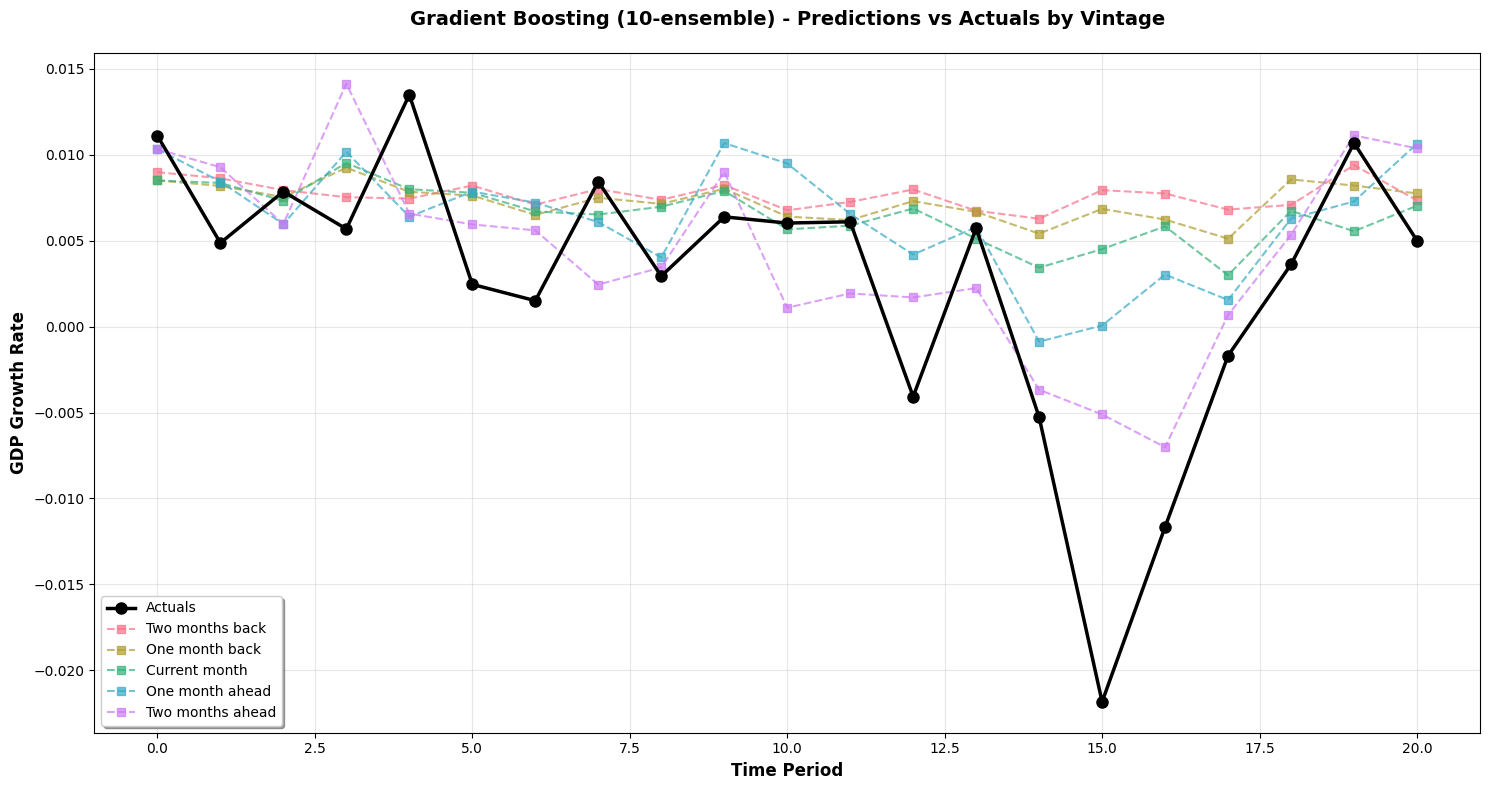

In [6]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('Gradient Boosting (10-ensemble)')
plt.show()

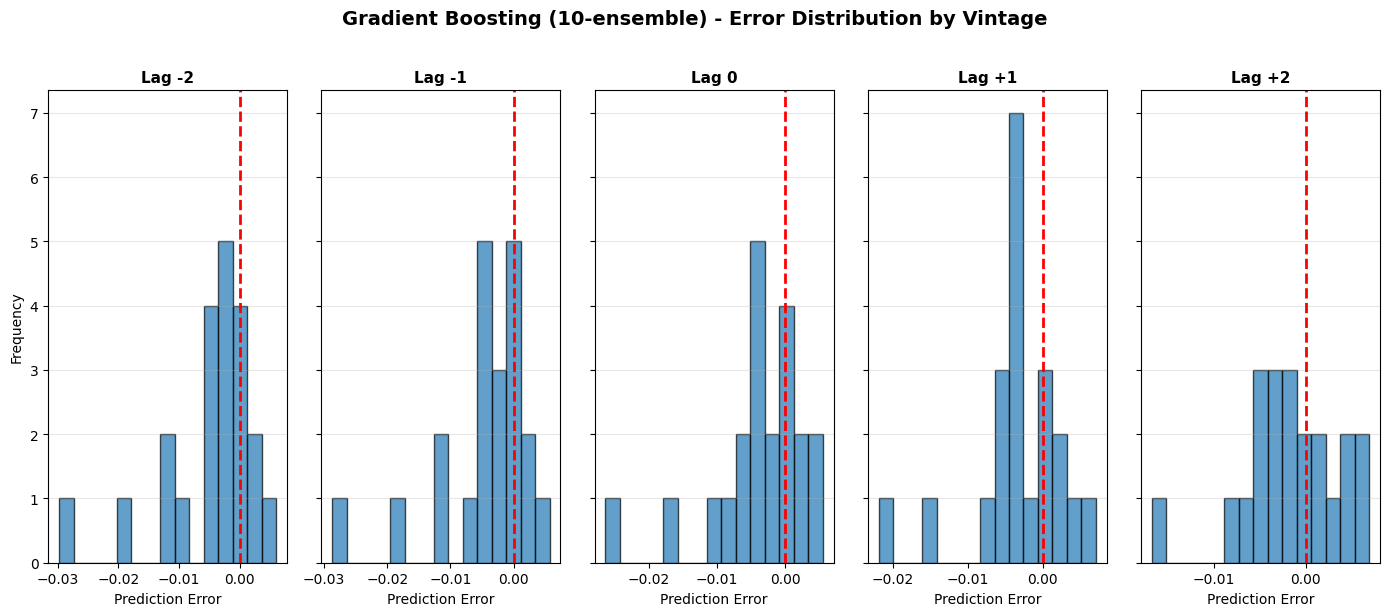

In [7]:
# Plot error distribution
fig2 = viz.plot_error_distribution('Gradient Boosting (10-ensemble)')
plt.show()

## 6. Production Inference

In [8]:
# Create inference pipeline
inference = InferencePipeline(gb_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.007544336529475311
target_variable     : gdpc1
n_models            : 10
model_class         : GradientBoostingRegressor


## Summary

This notebook implements Gradient Boosting regression from scikit-learn for GDP nowcasting. Like XGBoost, this builds an ensemble of trees sequentially, but with different algorithmic choices. We use absolute error loss for robustness and average predictions from 10 models.

With 6 lags and 100 estimators, this configuration balances model complexity with computational efficiency. The framework approach handles the backtesting mechanics, making it straightforward to compare this against other boosting and ensemble methods.